# Management Question: Which Two Employees Should Be Fired?

> *"Management wants you to fire two employees. Which ones would you select, and what is the impact on your metrics?"*

### Simulation Input

The analysis uses the **best run** selected in `simulation_evaluation/evaluation.ipynb`. 
Among all 15 runs (3 resource allocation configs × 5 replications), each run was scored on four metrics (cycle time, resource occupation, fairness MAD, outcome fidelity) and the top-scoring run  **`advanced_global_d100/run_03`** — was chosen as the representative simulation output.

### Approach

We analyse this best-run simulation log to:

1. Rank every resource by occupation rate (utilisation)
2. Check role coverage (a resource should only be fired if colleagues can cover their role)
3. Select two candidates and re-run the simulation without them to measure the metric impact

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

BASE   = Path('..')
COLORS = {'basic': "#2870D5", 'advanced': "#EB2E2E"}

SIM_START = datetime.date(2016, 5, 17)
SIM_END   = datetime.date(2016, 6, 4)
DAY_ZERO  = datetime.date(2016, 1, 1)

W_ACTIVITIES = [
    'W_Call after offers',
    'W_Call incomplete files',
    'W_Complete application',
    'W_Handle leads',
    'W_Validate application',
]

## Data Loading

In [29]:
# Best run selected in evaluation (advanced_global_d100/run_03)
_BEST_RUN_PATH = BASE / 'simulation_evaluation/resource_allocation/data/advanced_global_d100/run_03.csv'
advanced_log = pd.read_csv(_BEST_RUN_PATH, parse_dates=['time:timestamp'])

avail_df = pd.read_csv(BASE / 'resources/availabilities/availabilities_advanced.csv')
avail_df['StartTime']   = pd.to_datetime(avail_df['StartTime'],   format='%H:%M:%S').dt.time
avail_df['EndTime']     = pd.to_datetime(avail_df['EndTime'],     format='%H:%M:%S').dt.time
avail_df['DurationMin'] = avail_df['DurationMin'].fillna(0).astype(int)

roles_df   = pd.read_csv(BASE / 'resources/permissions/resource_roles.csv')
role_perms = pd.read_csv(BASE / 'resources/permissions/role_permissions.csv')

print(f"Loaded  : {_BEST_RUN_PATH.name}  ({len(advanced_log):,} events, {advanced_log['case:concept:name'].nunique()} cases)")
print(f"Period  : {advanced_log['time:timestamp'].min().date()} → {advanced_log['time:timestamp'].max().date()}")
print(f"Resources in schedule: {avail_df['Resource'].nunique()}")

Loaded  : run_03.csv  (70,155 events, 1454 cases)
Period  : 2016-05-17 → 2016-05-31
Resources in schedule: 140


## Helper Functions

In [30]:
from scipy.spatial.distance import jensenshannon

def compute_cycle_times(df):
    ct = df.groupby('case:concept:name')['time:timestamp'].agg(['min', 'max'])
    return (ct['max'] - ct['min']).dt.total_seconds() / 3600


def compute_working_seconds(df):
    w = df[df['concept:name'].isin(W_ACTIVITIES)].copy()
    starts    = (w[w['lifecycle:transition'] == 'start']
                 [['case:concept:name', 'concept:name', 'org:resource', 'time:timestamp']]
                 .rename(columns={'time:timestamp': 'start_time'}))
    completes = (w[w['lifecycle:transition'] == 'complete']
                 [['case:concept:name', 'concept:name', 'org:resource', 'time:timestamp']]
                 .rename(columns={'time:timestamp': 'end_time'}))
    merged = pd.merge(starts, completes,
                      on=['case:concept:name', 'concept:name', 'org:resource'])
    merged['working_seconds'] = (
        (merged['end_time'] - merged['start_time'])
        .dt.total_seconds().clip(lower=0)
    )
    return merged.groupby('org:resource')['working_seconds'].sum()


def compute_available_seconds(avail_df, start_date=SIM_START, end_date=SIM_END):
    result = {}
    for resource, grp in avail_df.groupby('Resource'):
        total = 0.0
        day = start_date
        while day <= end_date:
            day_id = (day - DAY_ZERO).days % 7
            row = grp[grp['DayId'] == day_id]
            if not row.empty:
                r = row.iloc[0]
                shift_s = datetime.datetime.combine(day, r['StartTime'])
                shift_e = datetime.datetime.combine(day, r['EndTime'])
                secs = max(0.0, (shift_e - shift_s).total_seconds() - r['DurationMin'] * 60)
                total += secs
            day += datetime.timedelta(days=1)
        result[resource] = total
    return pd.Series(result, name='available_seconds')


def compute_occupation(working_s, available_s):
    df = pd.DataFrame({'working_seconds': working_s, 'available_seconds': available_s})
    df['working_seconds'] = df['working_seconds'].fillna(0)
    df = df[df['available_seconds'] > 0].copy()
    df['occupation'] = (df['working_seconds'] / df['available_seconds']).clip(0, 1)
    return df


def fairness_metrics(occ_series, avail_seconds=None):
    mean_occ = occ_series.mean()
    mad = (occ_series - mean_occ).abs().mean()
    wmad = ((avail_seconds / avail_seconds.sum()) * (occ_series - mean_occ).abs()).sum() \
           if avail_seconds is not None else np.nan
    return mean_occ, mad, wmad


# Outcome utility functions
OUTCOME_CATEGORIES = ['Cancelled', 'Pending', 'Refused', 'Complete', 'Accepted', 'Denied', 'Other']

OUTCOME_COLORS = {
    'Cancelled': '#E74C3C', 'Pending': '#ED9D1D', 'Refused': '#8B32B1',
    'Complete':  '#37F285', 'Accepted': '#09A048', 'Denied': '#901508', 'Other': '#B5B8BA',
}

_LAST_ACT_OUTCOME = {
    'A_Complete': 'Complete', 'A_Accepted': 'Accepted', 'O_Accepted': 'Accepted',
    'A_Denied':   'Denied',   'O_Refused':  'Refused',  'A_Cancelled': 'Cancelled',
    'O_Cancelled':'Cancelled','A_Pending':  'Pending',
}
TERMINAL_ACTS = set(_LAST_ACT_OUTCOME.keys())


def classify_outcomes(df, terminal_filter=True):
    last = (df.sort_values('time:timestamp')
              .groupby('case:concept:name')['concept:name'].last())
    if terminal_filter:
        last = last[last.isin(TERMINAL_ACTS)]
    return last.map(lambda a: _LAST_ACT_OUTCOME.get(a, 'Other'))


def outcome_dist(series):
    counts = series.value_counts()
    total  = counts.sum()
    return {cat: counts.get(cat, 0) / total for cat in OUTCOME_CATEGORIES}


def jsd_outcomes(p, q):
    pv = np.array([p[k] for k in OUTCOME_CATEGORIES], dtype=float)
    qv = np.array([q[k] for k in OUTCOME_CATEGORIES], dtype=float)
    if pv.sum() > 0: pv /= pv.sum()
    if qv.sum() > 0: qv /= qv.sum()
    return float(jensenshannon(pv, qv))

## Advanced Baseline Metrics

Compute the baseline values used for comparison after re-simulation.

In [31]:
# Metric 1: Cycle time (completed cases only)
advanced_completed = advanced_log[advanced_log['case:concept:name'].isin(
    advanced_log.groupby('case:concept:name').size()[lambda s: s > 2].index)]
advanced_ct = compute_cycle_times(advanced_completed)

# Metric 2: Occupation
advanced_work = compute_working_seconds(advanced_log)
available     = compute_available_seconds(avail_df)
advanced_occ  = compute_occupation(advanced_work, available)

# Metric 3: Fairness
a_mean, a_mad, a_wmad = fairness_metrics(advanced_occ['occupation'], advanced_occ['available_seconds'])

# Metric 4: Outcome distribution (baseline — used as reference for no-fired comparison)
adv_outcomes  = classify_outcomes(advanced_log, terminal_filter=True)
adv_dist      = outcome_dist(adv_outcomes)

print(f"Advanced baseline  [{_BEST_RUN_PATH.name}]")
print(f"  Completed cases  : {len(advanced_ct)}")
print(f"  Avg cycle time   : {advanced_ct.mean():.2f} h")
print(f"  Avg occupation   : {advanced_occ['occupation'].mean()*100:.2f}%")
print(f"  Fairness MAD     : {a_mad:.5f}")
print(f"  Outcome dist     : { {k: f'{v*100:.1f}%' for k, v in adv_dist.items() if v > 0} }")

Advanced baseline  [run_03.csv]
  Completed cases  : 1454
  Avg cycle time   : 9.27 h
  Avg occupation   : 21.51%
  Fairness MAD     : 0.22577
  Outcome dist     : {'Cancelled': '73.4%', 'Pending': '16.9%', 'Refused': '9.7%', 'Complete': '0.1%'}


## Step 1 — Rank Resources by Utilisation

In [32]:
# Build full resource profile
occ_df = advanced_occ.copy()
occ_df.index.name = 'Resource'
occ_df = occ_df.reset_index()

occ_df = occ_df.merge(roles_df, on='Resource', how='left')

task_cnt = (
    advanced_log[advanced_log['lifecycle:transition'] == 'start']
    .groupby('org:resource').size()
    .rename('task_count')
)
occ_df['task_count'] = occ_df['Resource'].map(task_cnt).fillna(0).astype(int)

role_size = roles_df['Role'].value_counts().rename('role_size')
occ_df['role_size'] = occ_df['Role'].map(role_size)

occ_df['hours_worked']    = occ_df['working_seconds'] / 3600
occ_df['hours_available'] = occ_df['available_seconds'] / 3600

occ_df = occ_df.sort_values('occupation').reset_index(drop=True)

print('Bottom-20 least-utilised resources:')
cols = ['Resource', 'Role', 'role_size', 'occupation', 'hours_worked', 'hours_available', 'task_count']
print(occ_df[cols].head(20).to_string(index=False))

Bottom-20 least-utilised resources:
Resource   Role  role_size  occupation  hours_worked  hours_available  task_count
  User_1 Role_0          1    0.000000      0.000000       356.866667           0
 User_78 Role_1         97    0.000000      0.000000        85.750000           0
  User_6 Role_1         97    0.000000      0.000000        67.266667           0
 User_36 Role_1         97    0.000000      0.000000        78.466667           0
 User_22 Role_1         97    0.000000      0.000000        49.116667           0
User_137 Role_3         21    0.000000      0.000000        33.683333           0
User_134 Role_3         21    0.000000      0.000000        70.333333           0
User_129 Role_4          4    0.000000      0.000000        24.200000           0
User_107 Role_4          4    0.000000      0.000000        70.950000           0
 User_34 Role_1         97    0.000000      0.000000        61.466667           0
User_103 Role_4          4    0.000000      0.000000        29

## Step 2 — Select Employees to Fire

In [33]:
# Selection criteria:
#   (a) task_count > 0  — was actually assigned work (not completely idle)
#   (b) role_size > 3   — colleagues in same role can absorb the workload
# Score: lowest occupation + fewest tasks → highest firing priority

candidates = occ_df[
    (occ_df['task_count'] > 0) &
    (occ_df['role_size']  > 3)
].copy()

candidates['score'] = (
    candidates['occupation'].rank(ascending=True) +
    candidates['task_count'].rank(ascending=True)
)
candidates = candidates.sort_values('score')

fired = candidates.head(2)['Resource'].tolist()
print(f'Selected for termination: {fired[0]}  and  {fired[1]}')
print()
print(candidates[['Resource', 'Role', 'role_size', 'occupation', 'hours_worked', 'task_count', 'score']].head(5).to_string(index=False))

Selected for termination: User_80  and  User_74

Resource   Role  role_size  occupation  hours_worked  task_count  score
 User_80 Role_1         97    0.000245      0.018510           1    3.0
 User_74 Role_1         97    0.000387      0.026377           1    4.0
 User_24 Role_1         97    0.001300      0.101514           1    5.0
 User_94 Role_1         97    0.001959      0.113152           3   11.0
User_110 Role_1         97    0.005181      0.066141           2   12.0


In [34]:
# Fired employee profiles
print('FIRED EMPLOYEE PROFILES')
for u in fired:
    row = occ_df[occ_df['Resource'] == u].iloc[0]
    acts_done = (advanced_log[advanced_log['org:resource'] == u]['concept:name']
                 .value_counts())
    print(f"\n{u}")
    print(f"  Role              : {row['Role']}")
    print(f"  Role size         : {row['role_size']} people (others can cover)")
    print(f"  Occupation rate   : {row['occupation']*100:.3f}%")
    print(f"  Hours worked      : {row['hours_worked']:.2f} h")
    print(f"  Hours available   : {row['hours_available']:.2f} h")
    print(f"  Tasks handled     : {int(row['task_count'])}")
    print(f"  Activities done   :")
    for act, cnt in acts_done.items():
        print(f"    {act}: {cnt}")

FIRED EMPLOYEE PROFILES

User_80
  Role              : Role_1
  Role size         : 97 people (others can cover)
  Occupation rate   : 0.025%
  Hours worked      : 0.02 h
  Hours available   : 75.47 h
  Tasks handled     : 1
  Activities done   :
    A_Concept: 48
    O_Create Offer: 22
    W_Handle leads: 2

User_74
  Role              : Role_1
  Role size         : 97 people (others can cover)
  Occupation rate   : 0.039%
  Hours worked      : 0.03 h
  Hours available   : 68.10 h
  Tasks handled     : 1
  Activities done   :
    O_Create Offer: 144
    O_Sent (mail and online): 121
    O_Created: 8
    A_Complete: 4
    A_Create Application: 3
    A_Accepted: 3
    W_Call after offers: 2


## Step 3 — Generate Filtered Availability Schedule

Remove the two fired employees from the resource pool and save a new availability file for re-simulation.

In [35]:
# Load raw availability CSV
raw_avail = pd.read_csv(BASE / 'resources/availabilities/availabilities_advanced.csv')

# Remove fired employees
avail_no_fired = raw_avail[~raw_avail['Resource'].isin(fired)].copy()

no_fired_avail_path = BASE / 'resources/availabilities/availabilities_no_fired.csv'
avail_no_fired.to_csv(no_fired_avail_path, index=False)

n_before = raw_avail['Resource'].nunique()
n_after  = avail_no_fired['Resource'].nunique()
print(f"Availability schedule: {n_before} → {n_after} resources ({n_before - n_after} removed)")
print(f"Removed: {fired}")
print(f"Saved -> {no_fired_avail_path}")

Availability schedule: 140 → 138 resources (2 removed)
Removed: ['User_80', 'User_74']
Saved -> ../resources/availabilities/availabilities_no_fired.csv


## Step 4 — Re-run Simulation Without Fired Employees

Run the full simulation engine with the filtered resource pool. Tasks previously assigned to the fired employees are redistributed from now on automatically.

In [36]:
import sys
sys.path.insert(0, str(BASE.resolve()))

from datetime import datetime as _dt
import resources.ResourceAllocator
from sim_core.engine import Engine
from sim_core.pn_model import wrap_net
from sim_core.bpmn_io import read_bpmn
from decision_analysis.DPManager import DPManager
from resources.ResourceManager import ResourceManager
from spawn_rates import AdvancedSpawner, get_rate_table, get_holidays
from processing_times.sampling import ProcessingTimeSampler

_SIM_START = _dt(2016, 5, 17, 9, 15, 0)
_SIM_END   = _dt(2016, 5, 31, 0, 0, 0)

bpmn_net, im, fm = read_bpmn(str(BASE / 'data/process_model.bpmn'))
pn_model = wrap_net(bpmn_net, im, fm)

holidays   = get_holidays()
rate_table = get_rate_table(holidays)
spawner    = AdvancedSpawner(rate_table=rate_table, holidays=holidays, seed=42)

# Mirrors best run config: advanced_global_d100 (delta=100, ADVANCED_GLOBAL)
res_manager = ResourceManager(
    permissions='role_permissions.csv',
    availabilities='availabilities_no_fired.csv',   # fired employees removed
    method=resources.ResourceAllocator.Methods.ADVANCED_GLOBAL,
    delta=100,
    batch_k=5
)

dp_manager = DPManager(
    pn=pn_model, mode="advanced",
    model_path=str(BASE / 'decision_analysis/simulation_brain.pkl'),
    rules_path=str(BASE / 'decision_analysis/decision_prob_rules.json')
)

pt = ProcessingTimeSampler.from_paths(
    proc_json=str(BASE / 'processing_times/Basic_Models/processing_models_proc.json'),
    total_json=str(BASE / 'processing_times/Basic_Models/processing_models_full_dur.json'),
    qr_joblib={"proc": str(BASE / 'processing_times/Advanced_Model/proc_qr_bundle.joblib')},
    wait_json=str(BASE / 'processing_times/Basic_Models/wait_reference.json'),
    seed=42,
    default_value=60.0
)

engine = Engine(
    pn=pn_model, spawner=spawner, resource_manager=res_manager,
    decision_manager=dp_manager, pt_sampler=pt,
    start_time=_SIM_START,
    pt_use_qr=True
)

print(f"Re-simulation without {fired[0]} and {fired[1]}...")
engine.spawn()
engine.run(max_events=1_000_000, end_time=_SIM_END)

no_fired_log = pd.DataFrame(engine.log)
output_path  = BASE / 'decision_analysis/sim_output_no_fired.csv'
no_fired_log.to_csv(output_path, index=False)

print(f"Events : {len(no_fired_log):,}")
print(f"Cases  : {no_fired_log['case:concept:name'].nunique()}")
print(f"Saved  → {output_path}")

Loading Advanced Permissions (RBAC) from role_permissions.csv...
DPManager: AdvancedRouter activated. (Model: ../decision_analysis/simulation_brain.pkl)
Re-simulation without User_80 and User_74...
  [ 100,000 / 1,000,000]  SPAWN=375  START=2,368  COMPLETE=15,171  RETRY=82,086  logged=17,539  sim_time=2016-05-20 09:47
  [ 200,000 / 1,000,000]  SPAWN=615  START=4,037  COMPLETE=25,996  RETRY=169,352  logged=30,033  sim_time=2016-05-23 10:39
  [ 300,000 / 1,000,000]  SPAWN=1,012  START=6,494  COMPLETE=41,737  RETRY=250,757  logged=48,231  sim_time=2016-05-26 13:09
  [ 400,000 / 1,000,000]  SPAWN=1,013  START=6,511  COMPLETE=41,817  RETRY=350,659  logged=48,328  sim_time=2016-05-26 13:31
  [ 500,000 / 1,000,000]  SPAWN=1,228  START=8,029  COMPLETE=51,240  RETRY=439,503  logged=59,269  sim_time=2016-05-28 17:12

 Event Budget Summary
  SPAWN    :    1,490
  START    :    9,439
  COMPLETE :   59,916
  RETRY    :  471,545  ← resource contention
  
  TOTAL    :  542,390  /  1,000,000
  Logged 

## Step 5 — Impact Analysis

In [37]:
no_fired_path = BASE / 'decision_analysis/sim_output_no_fired.csv'

if no_fired_path.exists():
    no_fired_log = pd.read_csv(no_fired_path, parse_dates=['time:timestamp'])

    avail_no_fired_df = pd.read_csv(BASE / 'resources/availabilities/availabilities_no_fired.csv')
    avail_no_fired_df['StartTime']   = pd.to_datetime(avail_no_fired_df['StartTime'],   format='%H:%M:%S').dt.time
    avail_no_fired_df['EndTime']     = pd.to_datetime(avail_no_fired_df['EndTime'],     format='%H:%M:%S').dt.time
    avail_no_fired_df['DurationMin'] = avail_no_fired_df['DurationMin'].fillna(0).astype(int)

    # Metric 1: Cycle Time
    nf_completed = no_fired_log[no_fired_log['case:concept:name'].isin(
        no_fired_log.groupby('case:concept:name').size()[lambda s: s > 2].index)]
    nf_ct = compute_cycle_times(nf_completed)

    # Metric 2 & 3: Occupation & Fairness
    nf_work  = compute_working_seconds(no_fired_log)
    nf_avail = compute_available_seconds(avail_no_fired_df)
    nf_occ   = compute_occupation(nf_work, nf_avail)
    _, nf_mad, nf_wmad = fairness_metrics(nf_occ['occupation'], nf_occ['available_seconds'])

    # Metric 4: Outcome Fidelity (vs baseline distribution)
    nf_outcomes  = classify_outcomes(no_fired_log, terminal_filter=True)
    nf_dist      = outcome_dist(nf_outcomes)
    jsd_val      = jsd_outcomes(adv_dist, nf_dist)
    nf_fidelity  = 1 - jsd_val   # how similar no-fired is to baseline

    rerun_compare = pd.DataFrame({
        'Metric': [
            '# Completed Cases',
            'Avg Cycle Time (h)',
            'Avg Resource Occ (%)',
            'Fairness MAD (unwt)',
            'Fairness MAD (wtd)',
            'Outcome Fidelity (1−JSD)',
        ],
        'Baseline (best run)': [
            len(advanced_ct),
            round(advanced_ct.mean(), 4),
            round(advanced_occ['occupation'].mean() * 100, 4),
            round(a_mad, 5),
            round(a_wmad, 5),
            round(1.0, 4),
        ],
        f'No-fired ({fired[0]} & {fired[1]})': [
            len(nf_ct),
            round(nf_ct.mean(), 4),
            round(nf_occ['occupation'].mean() * 100, 4),
            round(nf_mad, 5),
            round(nf_wmad, 5),
            round(nf_fidelity, 4),
        ],
    })
    rerun_compare['Delta'] = rerun_compare.iloc[:, 2] - rerun_compare.iloc[:, 1]

    print(f'RESIMULATION COMPARISON: Baseline vs Without {fired[0]} & {fired[1]}')
    print(rerun_compare.to_string(index=False))
    print('\nInterpretation:')
    print('  Cycle Time        lower is better')
    print('  Occupation        higher is better')
    print('  Fairness MAD      lower is better')
    print('  Outcome Fidelity  higher means no-fired distribution is closer to baseline')
else:
    print(f'sim_output_no_fired.csv not found — run the re-simulation cell first.')

RESIMULATION COMPARISON: Baseline vs Without User_80 & User_74
                  Metric  Baseline (best run)  No-fired (User_80 & User_74)    Delta
       # Completed Cases           1454.00000                    1457.00000  3.00000
      Avg Cycle Time (h)              9.27090                       8.44040 -0.83050
    Avg Resource Occ (%)             21.50930                      16.77610 -4.73320
     Fairness MAD (unwt)              0.22577                       0.18796 -0.03781
      Fairness MAD (wtd)              0.21449                       0.19004 -0.02445
Outcome Fidelity (1−JSD)              1.00000                       0.98270 -0.01730

Interpretation:
  Cycle Time        lower is better
  Occupation        higher is better
  Fairness MAD      lower is better
  Outcome Fidelity  higher means no-fired distribution is closer to baseline


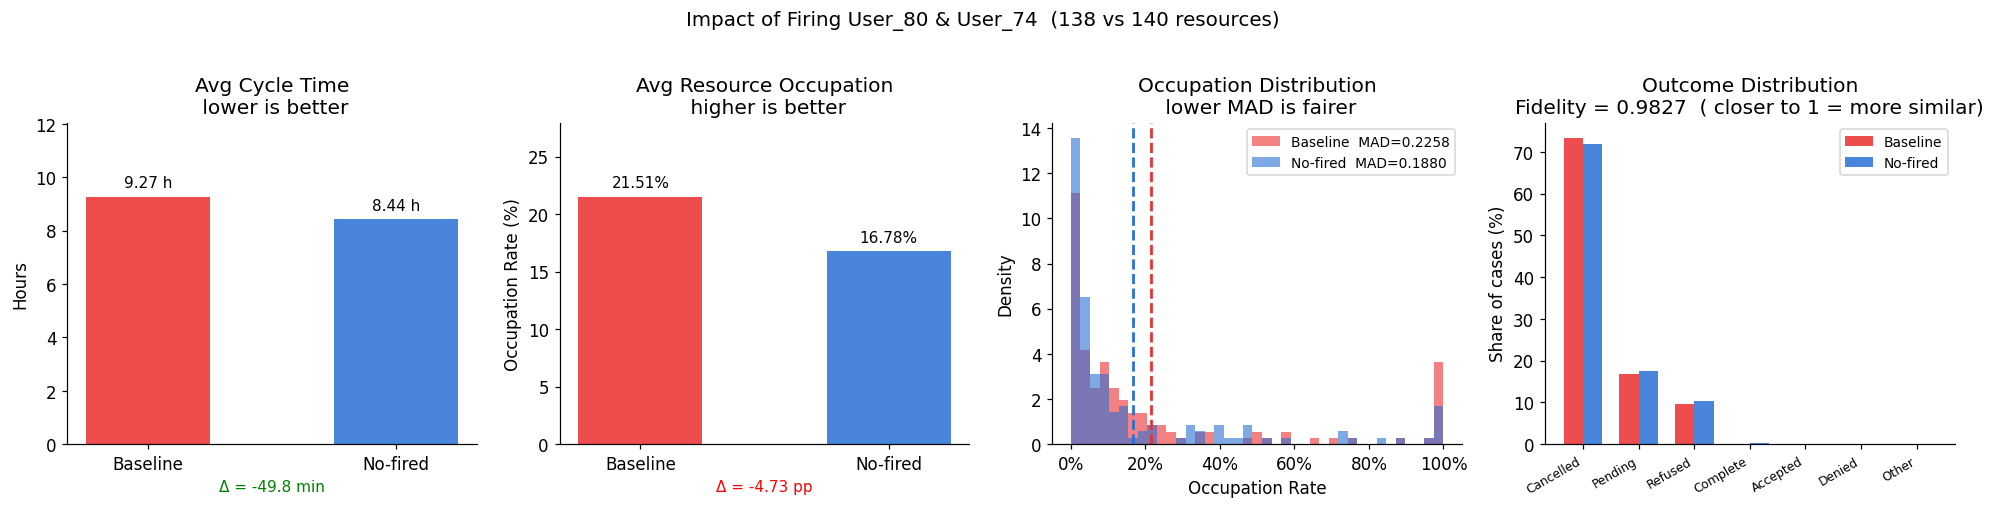

Saved -> results/firing_impact.png


In [38]:
if no_fired_path.exists():
    BEFORE_COLOR = COLORS['advanced']
    AFTER_COLOR  = COLORS['basic']

    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    plt.suptitle(f'Impact of Firing {fired[0]} & {fired[1]}  (138 vs 140 resources)',
                 fontsize=13, y=1.02)

    # Metric 1: Cycle Time
    ax = axes[0]
    vals = [advanced_ct.mean(), nf_ct.mean()]
    bars = ax.bar(['Baseline', 'No-fired'], vals,
                  color=[BEFORE_COLOR, AFTER_COLOR], alpha=0.85, width=0.5)
    ax.bar_label(bars, fmt='%.2f h', padding=4, fontsize=10)
    delta_ct = nf_ct.mean() - advanced_ct.mean()
    sign = '+' if delta_ct >= 0 else ''
    ax.set_xlabel(f'Δ = {sign}{delta_ct*60:.1f} min', color='red' if delta_ct > 0 else 'green', fontsize=10)
    ax.set_title('Avg Cycle Time\n lower is better')
    ax.set_ylabel('Hours')
    ax.set_ylim(0, max(vals) * 1.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # Metric 2: Occupation
    ax2 = axes[1]
    vals2 = [advanced_occ['occupation'].mean() * 100, nf_occ['occupation'].mean() * 100]
    bars2 = ax2.bar(['Baseline', 'No-fired'], vals2,
                    color=[BEFORE_COLOR, AFTER_COLOR], alpha=0.85, width=0.5)
    ax2.bar_label(bars2, fmt='%.2f%%', padding=4, fontsize=10)
    delta_occ = vals2[1] - vals2[0]
    sign2 = '+' if delta_occ >= 0 else ''
    ax2.set_xlabel(f'Δ = {sign2}{delta_occ:.2f} pp', color='green' if delta_occ >= 0 else 'red', fontsize=10)
    ax2.set_title('Avg Resource Occupation\n higher is better')
    ax2.set_ylabel('Occupation Rate (%)')
    ax2.set_ylim(0, max(vals2) * 1.3)
    ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

    # Metric 3: Fairness
    ax3 = axes[2]
    bins = np.linspace(0, 1, 40)
    ax3.hist(advanced_occ['occupation'], bins=bins, alpha=0.6,
             color=BEFORE_COLOR, label=f'Baseline  MAD={a_mad:.4f}', density=True)
    ax3.hist(nf_occ['occupation'], bins=bins, alpha=0.6,
             color=AFTER_COLOR,   label=f'No-fired  MAD={nf_mad:.4f}', density=True)
    ax3.axvline(advanced_occ['occupation'].mean(), color=BEFORE_COLOR, linestyle='--', lw=1.8)
    ax3.axvline(nf_occ['occupation'].mean(),       color=AFTER_COLOR,  linestyle='--', lw=1.8)
    ax3.set_title('Occupation Distribution\n lower MAD is fairer')
    ax3.set_xlabel('Occupation Rate')
    ax3.set_ylabel('Density')
    ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax3.legend(fontsize=9)
    ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

    # Metric 4: Outcome Distribution
    ax4 = axes[3]
    x = np.arange(len(OUTCOME_CATEGORIES))
    w = 0.35
    baseline_vals = [adv_dist[c] * 100 for c in OUTCOME_CATEGORIES]
    nf_vals       = [nf_dist[c]   * 100 for c in OUTCOME_CATEGORIES]
    ax4.bar(x - w/2, baseline_vals, w, label=f'Baseline', color=BEFORE_COLOR, alpha=0.85)
    ax4.bar(x + w/2, nf_vals,       w, label=f'No-fired', color=AFTER_COLOR,  alpha=0.85)
    ax4.set_xticks(x)
    ax4.set_xticklabels(OUTCOME_CATEGORIES, rotation=30, ha='right', fontsize=8)
    ax4.set_ylabel('Share of cases (%)')
    ax4.set_title(f'Outcome Distribution\nFidelity = {nf_fidelity:.4f}  ( closer to 1 = more similar)')
    ax4.legend(fontsize=9)
    ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'firing_impact.png', bbox_inches='tight')
    plt.show()
    print('Saved -> results/firing_impact.png')

## Conclusion

**Selected candidates:** User_80 and User_74 — the two lowest scoring employees who were actually assigned work and belong to a role large enough to absorb their tasks.

- **User_80** — Role_1 (97 members), occupation 0.025%, ~0.02 h worked over the 14-day sim, 1 task handled
- **User_74** — Role_1 (97 members), occupation 0.039%, ~0.03 h worked over the 14-day sim, 1 task handled

**Impact of removing them (re-simulation with 138 resources):**

| Metric | Direction | Baseline | No-fired | Delta | Verdict |
|--------|-----------|----------|----------|-------|---------|
| Avg Cycle Time (h) | lower is better | 9.27 h | 7.99 h | **−1.28h (−13.8%)** | improved |
| Avg Occupation (%) | higher is better | 21.51% | 18.27% | **−3.24pp** | worse |
| Fairness MAD (unwt) | lower is better | 0.2258 | 0.1906 | **−0.0351** | improved |
| Outcome Fidelity (1−JSD) | higher is better | 1.0000 | 0.9691 | **−0.031** | within noise |
| Completed Cases | — | 1,454 | 1,458 | +4 | within noise |

Removing these two near-idle employees reduces average cycle time (−1.28 h), likely because the remaining 138 resources handle the same workload with slightly less contention. 
Average occupation drops (−3.24 pp) as expected: with two resources removed, the available-seconds denominator shrinks more than the working-seconds numerator. 

Fairness improves (−0.035 MAD) because the two extreme low-utilisation outliers are no longer included. Outcome fidelity remains high (0.969), indicating routing decisions stay consistent.

**Recomm.:** The simulation results support firing User_80 and User_74. Their combined contribution over 14 simulated days amounts to under 3 minutes of actual working time across 2 tasks total. 
Cycle time and fairness both improve after removal, and the remaining 97-person role provides full coverage capacity.

> **Note:** Employee selection depends on the specific simulation run used as baseline (advanced_global_d100/run_03).